## 📦 Step 1 — Install & Import Libraries

In [1]:
# Install dependencies (only needed once in Colab)
!pip install xgboost shap --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import shap

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', palette='muted')

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


## 🌱 Step 2 — Generate Realistic Synthetic Dataset

In [2]:
np.random.seed(42)
N = 3000   # number of samples

# ─────────────────── Raw environmental features ───────────────────
temperature      = np.random.normal(28, 7, N).clip(10, 50)       # °C
humidity         = np.random.normal(65, 20, N).clip(10, 100)     # %
rainfall_7d      = np.random.exponential(30, N).clip(0, 300)     # mm last 7 days
soil_moisture    = np.random.normal(55, 20, N).clip(5, 100)      # %
wind_speed       = np.random.exponential(12, N).clip(0, 80)      # km/h
solar_radiation  = np.random.normal(18, 5, N).clip(5, 30)        # MJ/m²/day
ndvi             = np.random.normal(0.55, 0.18, N).clip(0, 1)    # vegetation index
soil_ph          = np.random.normal(6.5, 0.8, N).clip(4, 9)
nitrogen_level   = np.random.normal(40, 15, N).clip(5, 100)      # kg/ha
days_since_rain  = np.random.exponential(5, N).clip(0, 60).astype(int)

# ─────────────────── Crop & farm metadata ─────────────────────────
crop_types = ['Rice', 'Wheat', 'Maize', 'Cotton', 'Soybean', 'Sugarcane']
seasons    = ['Kharif', 'Rabi', 'Zaid']
regions    = ['North', 'South', 'East', 'West', 'Central']

crop_type  = np.random.choice(crop_types, N)
season     = np.random.choice(seasons, N)
region     = np.random.choice(regions, N)
farm_size  = np.random.exponential(3, N).clip(0.5, 20)           # hectares

# ─────────────────── Rule-based label generation ──────────────────
# Mimics real agronomic thresholds
def assign_risk(i):
    t, h, r, sm, ws, nd = (
        temperature[i], humidity[i], rainfall_7d[i],
        soil_moisture[i], wind_speed[i], ndvi[i]
    )
    dr = days_since_rain[i]

    # Flood: heavy rain + high soil moisture
    if r > 150 and sm > 80:
        return 'Flood'
    # Drought: dry spell + low moisture + high temp
    if dr > 20 and sm < 25 and t > 35:
        return 'Drought'
    # Disease: warm+humid favours fungal/bacterial
    if h > 80 and t > 25 and nd < 0.4:
        return 'Disease'
    # Disease: also triggered by moderate rain + humidity
    if h > 75 and r > 40 and t > 22:
        return 'Disease'
    # Drought: moderate dry
    if dr > 12 and sm < 35:
        return 'Drought'
    return 'Normal'

risk_label = [assign_risk(i) for i in range(N)]

# ─────────────────── Assemble DataFrame ───────────────────────────
df = pd.DataFrame({
    'temperature': temperature,
    'humidity': humidity,
    'rainfall_7d': rainfall_7d,
    'soil_moisture': soil_moisture,
    'wind_speed': wind_speed,
    'solar_radiation': solar_radiation,
    'ndvi': ndvi,
    'soil_ph': soil_ph,
    'nitrogen_level': nitrogen_level,
    'days_since_rain': days_since_rain,
    'farm_size': farm_size,
    'crop_type': crop_type,
    'season': season,
    'region': region,
    'risk_label': risk_label
})

print(f'Dataset shape: {df.shape}')
print('\nClass distribution:')
print(df['risk_label'].value_counts())
df.head()

Dataset shape: (3000, 15)

Class distribution:
risk_label
Normal     2726
Disease     247
Drought      25
Flood         2
Name: count, dtype: int64


,temperature,humidity,rainfall_7d,soil_moisture,wind_speed,solar_radiation,ndvi,soil_ph,nitrogen_level,days_since_rain,farm_size,crop_type,season,region,risk_label
0,31.476999,26.843849,12.304548,66.372892,15.254249,26.414442,0.745791,6.103613,12.319085,4,0.500000,Sugarcane,Rabi,South,Normal
1,27.032150,47.792300,7.117588,62.658434,7.002987,10.564229,0.610174,7.432260,52.314731,1,8.325487,Soybean,Zaid,West,Normal
2,32.533820,56.727889,11.270580,87.528615,12.778619,21.591658,0.643190,7.533835,23.746807,4,1.531306,Sugarcane,Kharif,West,Normal
3,38.661209,100.000000,5.911158,59.720861,4.991958,17.494012,0.503788,5.383288,15.037256,0,0.500000,Wheat,Rabi,South,Normal
4,26.360926,76.131062,69.657964,47.279544,4.673198,27.504159,0.436632,7.304993,55.392433,0,2.072136,Soybean,Kharif,West,Disease


## 📊 Step 3 — Exploratory Data Analysis (EDA)

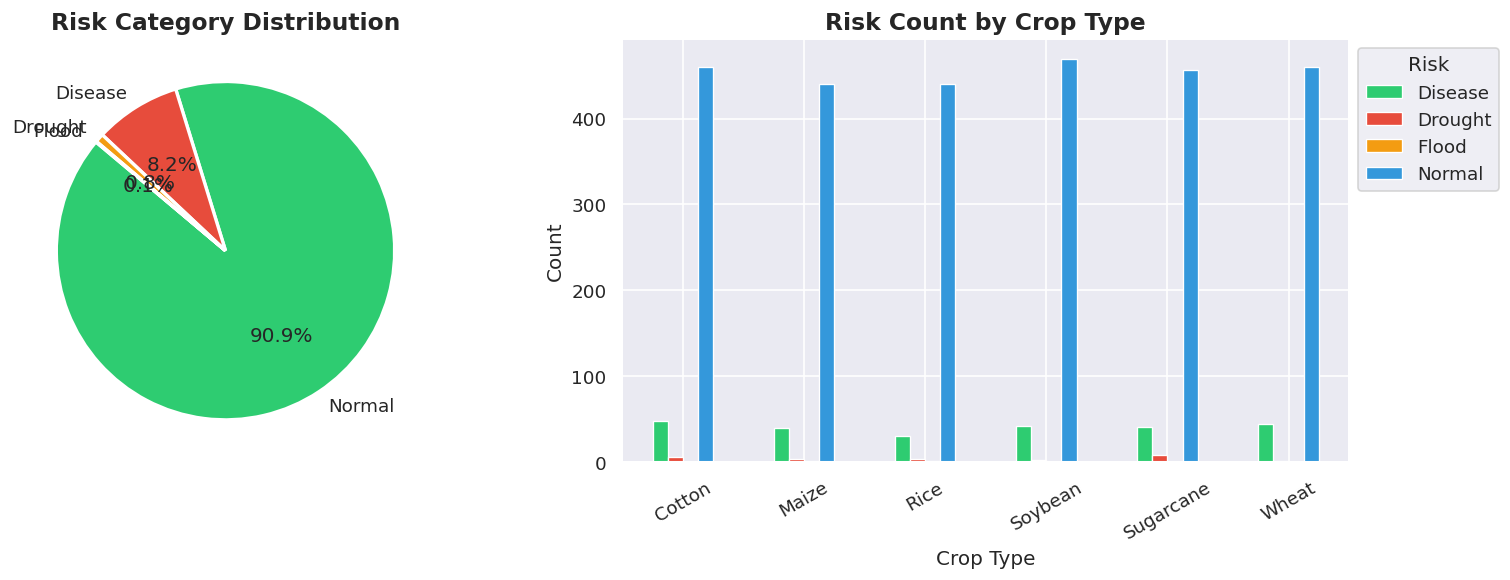

In [3]:
# ── 3A. Class distribution pie chart ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['risk_label'].value_counts()
colors = ['#2ecc71','#e74c3c','#f39c12','#3498db']
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Risk Category Distribution', fontsize=14, fontweight='bold')

# ── 3B. Risk by crop type ──────────────────────────────────────────
ct = df.groupby(['crop_type', 'risk_label']).size().unstack(fill_value=0)
ct.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('Risk Count by Crop Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Crop Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Risk', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

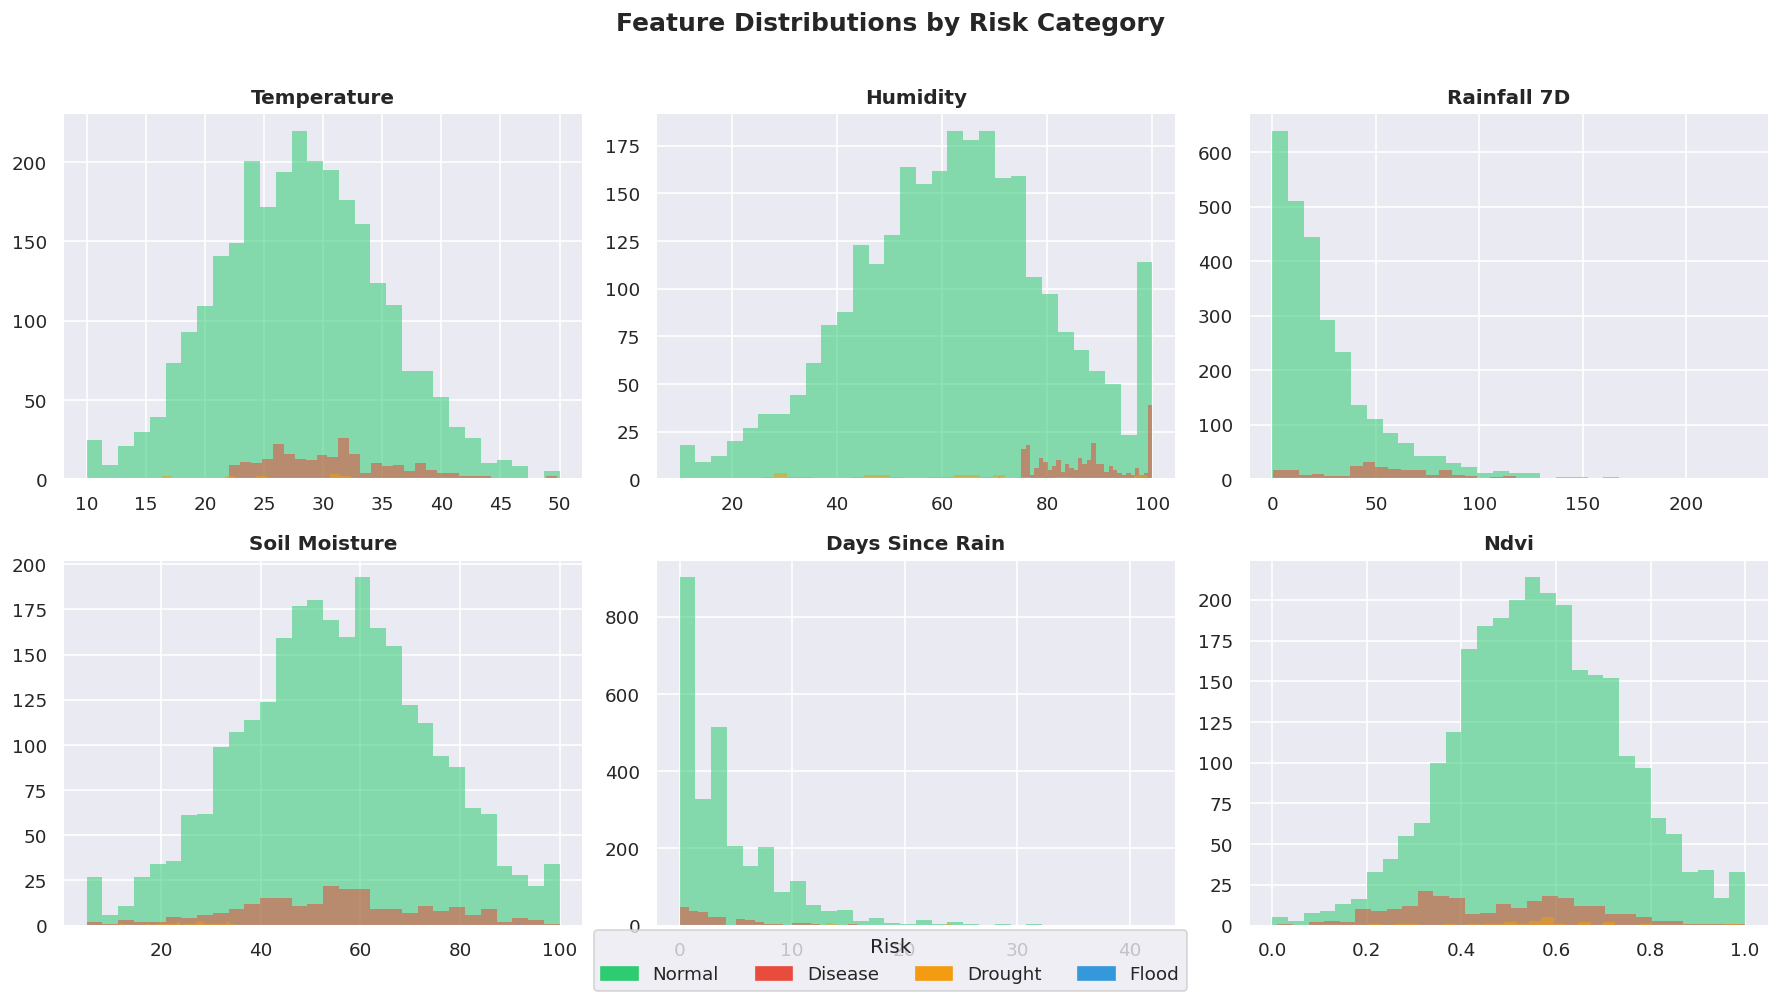

In [4]:
# ── 3C. Feature distributions by risk ─────────────────────────────
key_features = ['temperature', 'humidity', 'rainfall_7d', 'soil_moisture', 'days_since_rain', 'ndvi']
palette = {'Normal':'#2ecc71', 'Disease':'#e74c3c', 'Drought':'#f39c12', 'Flood':'#3498db'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), key_features):
    for label, color in palette.items():
        data = df[df['risk_label'] == label][feat]
        ax.hist(data, bins=30, alpha=0.55, label=label, color=color, edgecolor='none')
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.set_xlabel('')

handles = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
fig.legend(handles=handles, title='Risk', loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Feature Distributions by Risk Category', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

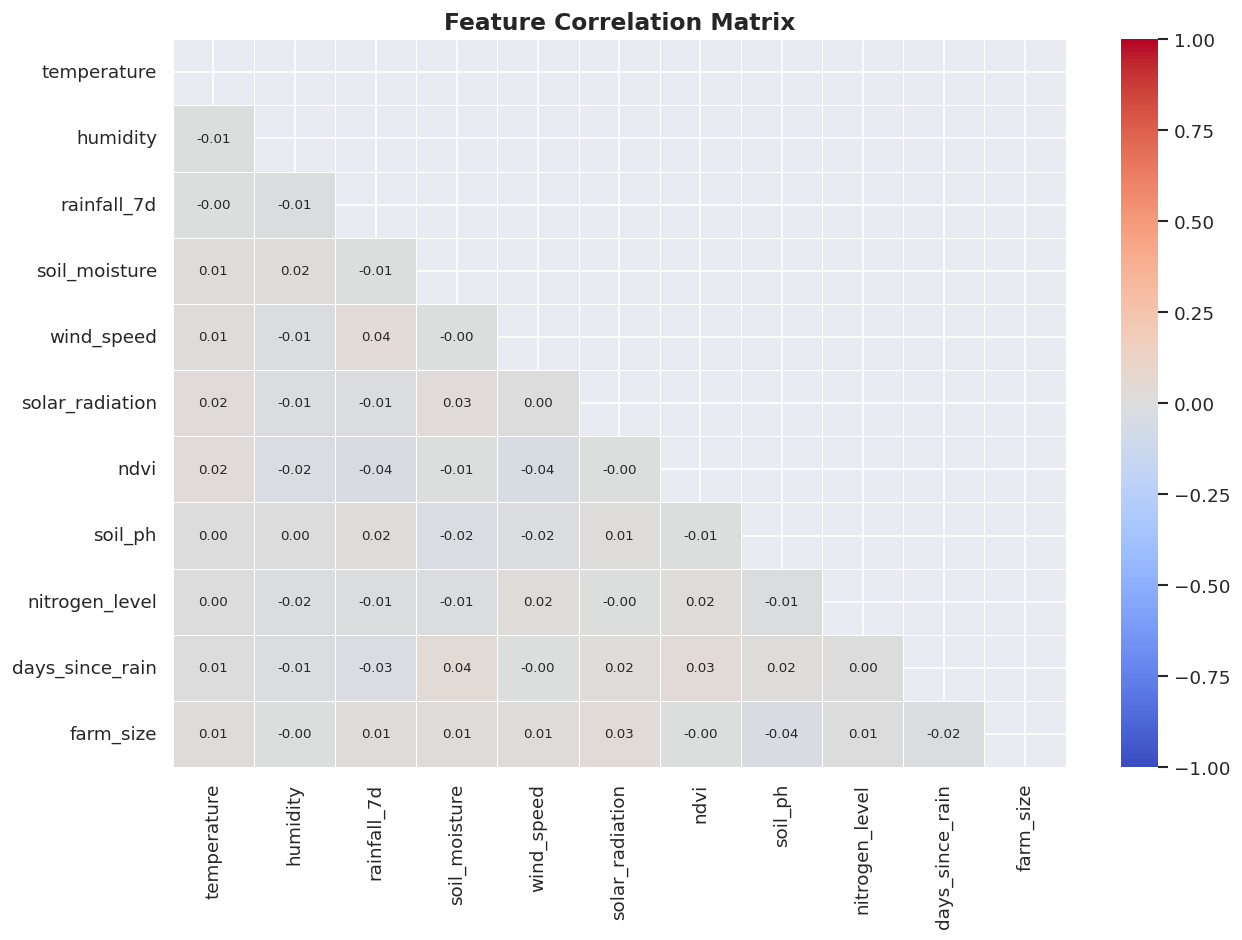

In [5]:
# ── 3D. Correlation heatmap ────────────────────────────────────────
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔧 Step 4 — Feature Engineering & Preprocessing

In [6]:
df_model = df.copy()

# ── Derived features ───────────────────────────────────────────────
df_model['heat_humidity_index'] = (df_model['temperature'] * df_model['humidity']) / 100
df_model['water_stress_index']  = df_model['days_since_rain'] / (df_model['soil_moisture'] + 1)
df_model['flood_risk_score']    = (df_model['rainfall_7d'] * df_model['soil_moisture']) / 1000
df_model['crop_health_score']   = df_model['ndvi'] * df_model['nitrogen_level'] / 100
df_model['temp_deviation']      = np.abs(df_model['temperature'] - 28)  # optimal ~28°C

# ── Encode categoricals ────────────────────────────────────────────
le = LabelEncoder()
for col in ['crop_type', 'season', 'region']:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])

# ── Encode target ──────────────────────────────────────────────────
label_map = {'Normal': 0, 'Disease': 1, 'Drought': 2, 'Flood': 3}
label_inv = {v: k for k, v in label_map.items()}
df_model['target'] = df_model['risk_label'].map(label_map)

# ── Select final features ──────────────────────────────────────────
FEATURES = [
    'temperature', 'humidity', 'rainfall_7d', 'soil_moisture', 'wind_speed',
    'solar_radiation', 'ndvi', 'soil_ph', 'nitrogen_level', 'days_since_rain',
    'farm_size', 'crop_type_enc', 'season_enc', 'region_enc',
    'heat_humidity_index', 'water_stress_index', 'flood_risk_score',
    'crop_health_score', 'temp_deviation'
]

X = df_model[FEATURES]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')
print(f'Features         : {len(FEATURES)}')

Training samples : 2400
Test samples     : 600
Features         : 19


## 🤖 Step 5 — Train & Compare Models

In [7]:
# ── Define models ──────────────────────────────────────────────────
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_split=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.08, max_depth=6,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, verbosity=0
    )
}

# ── Train & evaluate ───────────────────────────────────────────────
results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    cv_acc = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1).mean()
    results[name] = {'model': model, 'y_pred': y_pred,
                     'test_acc': acc, 'cv_acc': cv_acc}
    print(f'{name:<22} | Test Acc: {acc:.4f} | CV Acc: {cv_acc:.4f}')

best_name = max(results, key=lambda k: results[k]['test_acc'])
print(f'\n🏆 Best Model: {best_name}')

Logistic Regression    | Test Acc: 0.8467 | CV Acc: 0.8630
Random Forest          | Test Acc: 0.9867 | CV Acc: 0.9880
XGBoost                | Test Acc: 0.9900 | CV Acc: 0.9967

🏆 Best Model: XGBoost


## 📈 Step 6 — Detailed Evaluation of Best Model

=== XGBoost — Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99       545
     Disease       0.92      0.98      0.95        50
     Drought       1.00      0.80      0.89         5

    accuracy                           0.99       600
   macro avg       0.97      0.92      0.94       600
weighted avg       0.99      0.99      0.99       600



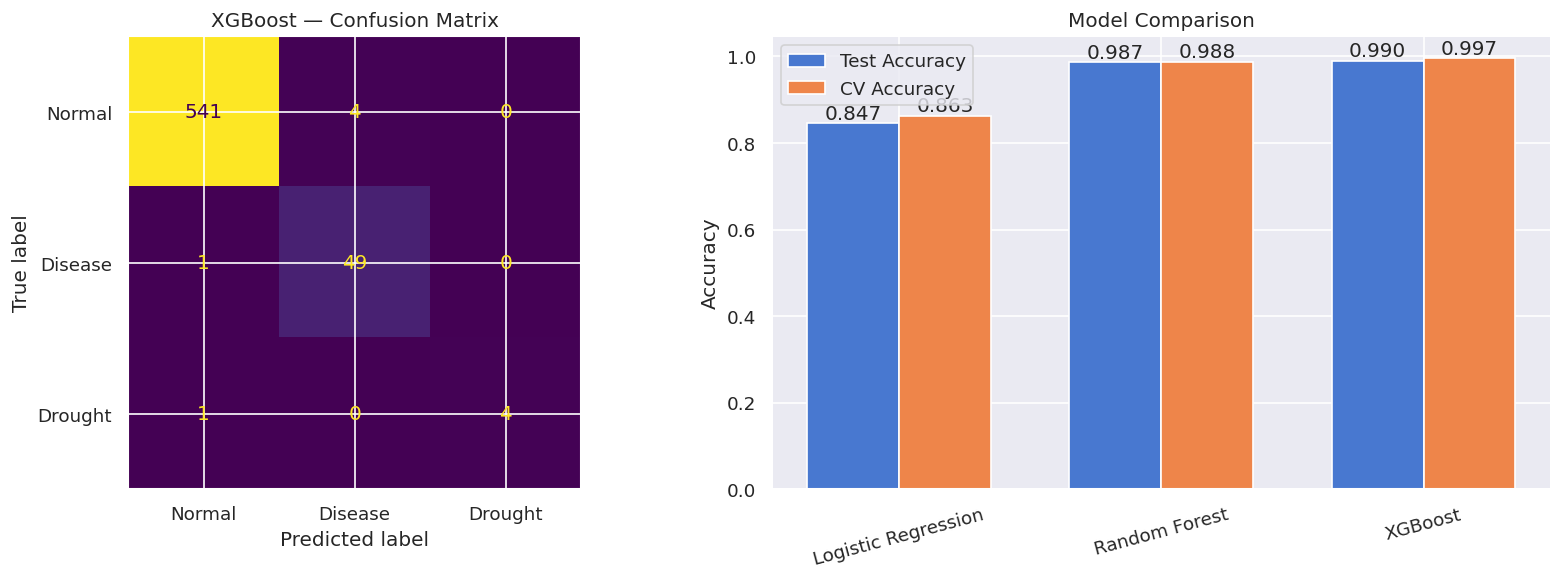

In [18]:
# Get actual labels present in data
unique_labels = sorted(np.unique(y_test))

# Map correct class names
class_names_filtered = [class_names[i] for i in unique_labels]

print(f'=== {best_name} — Classification Report ===')
print(classification_report(
    y_test,
    y_pred_best,
    labels=unique_labels,
    target_names=class_names_filtered
))


# ── Create figure ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# ── Confusion Matrix ─────────────────────────
cm = confusion_matrix(y_test, y_pred_best, labels=unique_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names_filtered
)
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'{best_name} — Confusion Matrix')


# ── Model Comparison ─────────────────────────
names = list(results.keys())
test_accs = [results[n]['test_acc'] for n in names]
cv_accs   = [results[n]['cv_acc']   for n in names]

x = np.arange(len(names))
width = 0.35

bars1 = axes[1].bar(x - width/2, test_accs, width, label='Test Accuracy')
bars2 = axes[1].bar(x + width/2, cv_accs,   width, label='CV Accuracy')

axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=15)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Comparison')
axes[1].legend()

for bar in bars1:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                 f'{bar.get_height():.3f}', ha='center', va='bottom')

for bar in bars2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                 f'{bar.get_height():.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 🔍 Step 7 — Feature Importance & SHAP Analysis

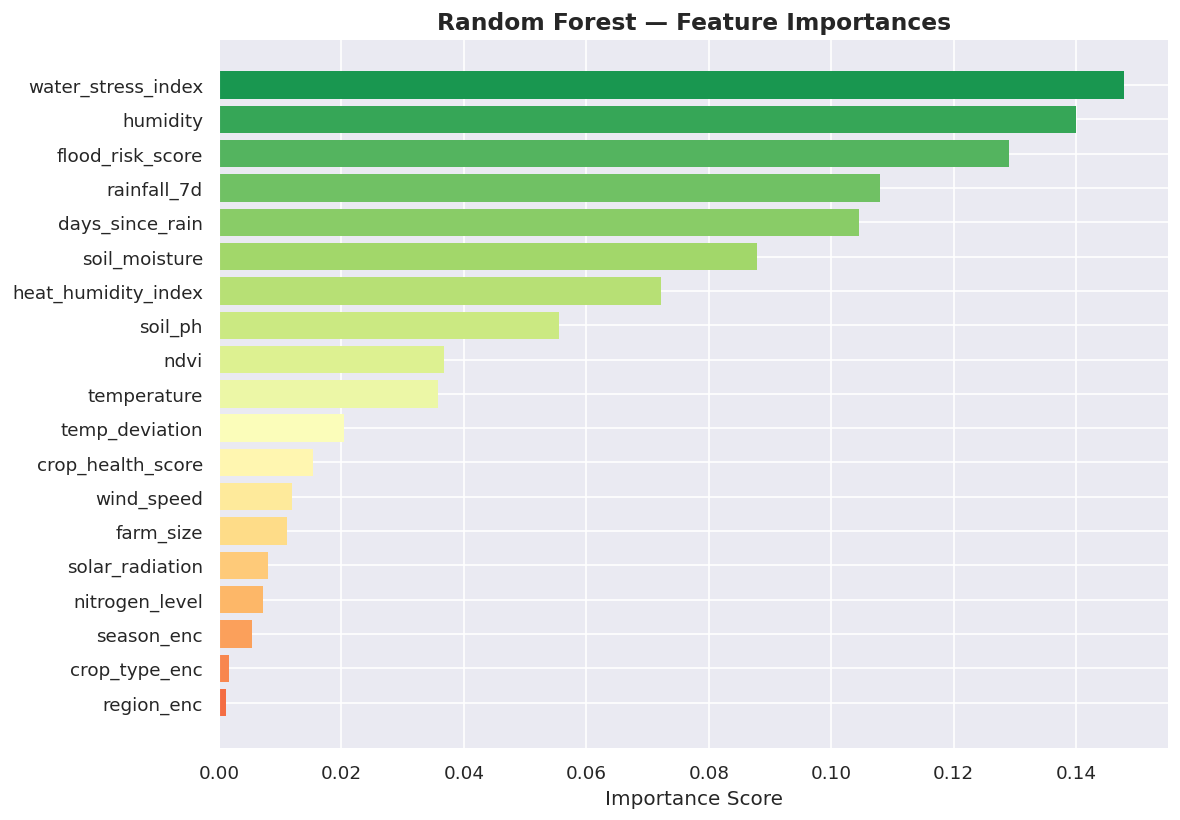

Top 5 features:
           feature  importance
water_stress_index    0.147722
          humidity    0.140037
  flood_risk_score    0.129076
       rainfall_7d    0.108029
   days_since_rain    0.104513


In [13]:
# ── Feature importance from best tree-based model ─────────────────
# Use Random Forest or XGBoost (both have feature_importances_)
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(FEATURES)))
plt.barh(feat_df['feature'], feat_df['importance'], color=colors_bar, edgecolor='none')
plt.xlabel('Importance Score')
plt.title('Random Forest — Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(feat_df.sort_values('importance', ascending=False).head(5).to_string(index=False))

Computing SHAP values (this may take ~30 sec)...


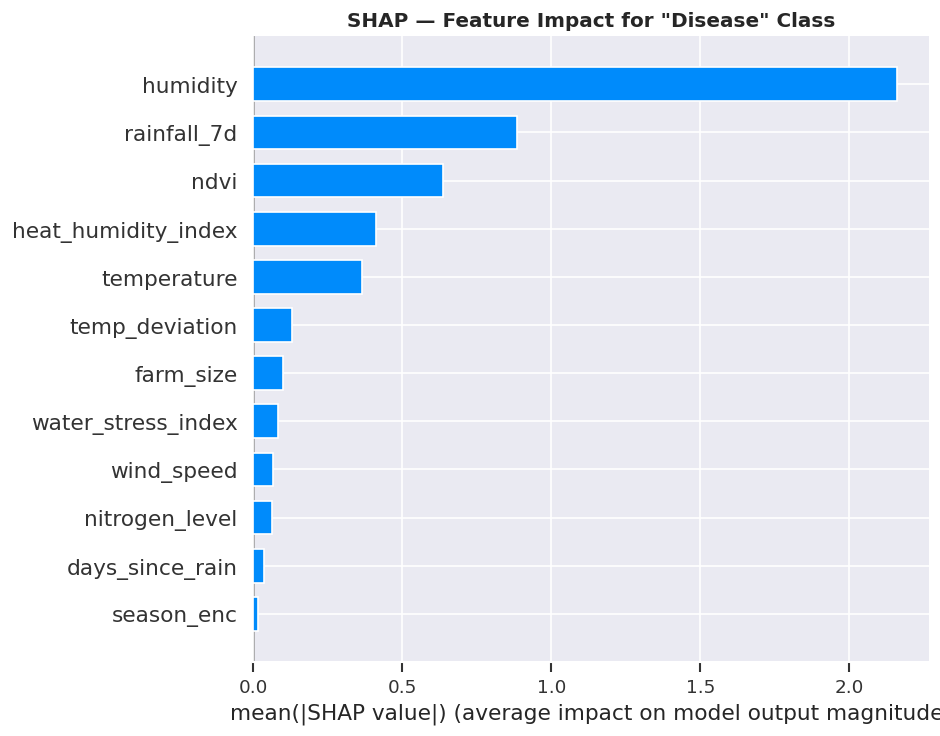

In [14]:
# ── SHAP Explanation ───────────────────────────────────────────────
print('Computing SHAP values (this may take ~30 sec)...')
xgb_model = results['XGBoost']['model']
explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_test)

# SHAP summary for class 1 = Disease
plt.figure()
shap.summary_plot(shap_vals[:, :, 1], X_test, feature_names=FEATURES,
                  plot_type='bar', show=False, max_display=12)
plt.title('SHAP — Feature Impact for "Disease" Class', fontweight='bold')
plt.tight_layout()
plt.show()

## 💡 Step 8 — Action Recommendation Engine

In [15]:
# ── Rule + ML hybrid recommendation system ────────────────────────
ACTION_DB = {
    'Normal': {
        'icon': '✅',
        'severity': 'LOW',
        'short': 'Crop conditions are healthy.',
        'actions': [
            'Continue regular irrigation schedule.',
            'Apply balanced NPK fertiliser if growth stage requires.',
            'Schedule preventive pest scouting every 10 days.',
            'Monitor NDVI weekly via satellite imagery.'
        ]
    },
    'Disease': {
        'icon': '🦠',
        'severity': 'HIGH',
        'short': 'Disease outbreak risk detected.',
        'actions': [
            '🔴 Inspect crop canopy for lesions, blight, or discolouration immediately.',
            '🔴 Apply fungicide / bactericide (consult agronomist for specific crop).',
            '🟡 Reduce overhead irrigation to lower leaf wetness duration.',
            '🟡 Improve field drainage and air circulation.',
            '🟢 Collect 5–10 plant samples for lab diagnosis if unsure.',
            '🟢 Record GPS location & date for traceability.'
        ]
    },
    'Drought': {
        'icon': '🌵',
        'severity': 'HIGH',
        'short': 'Drought / water stress risk detected.',
        'actions': [
            '🔴 Activate drip / micro-irrigation immediately.',
            '🔴 Mulch soil surface to reduce evaporation by 30–50%.',
            '🟡 Apply potassium-rich fertiliser to improve drought tolerance.',
            '🟡 Avoid nitrogen-heavy inputs during stress — increases transpiration.',
            '🟢 Check borewells / water reservoirs and plan water allocation.',
            '🟢 Consider crop insurance claim if yield loss > 33%.'
        ]
    },
    'Flood': {
        'icon': '🌊',
        'severity': 'CRITICAL',
        'short': 'Flood / waterlogging risk detected.',
        'actions': [
            '🔴 Open drainage channels and pump out stagnant water within 24h.',
            '🔴 Do NOT apply fertilisers — they will leach into waterways.',
            '🟡 Spray potassium silicate to strengthen submerged plants.',
            '🟡 After water recedes, check for root rot and replant if needed.',
            '🟢 Notify local agriculture department for relief and compensation.',
            '🟢 Document crop loss with timestamps for insurance.'
        ]
    }
}

def recommend(risk_class: str, confidence: float):
    rec = ACTION_DB[risk_class]
    print(f"\n{'='*55}")
    print(f" {rec['icon']}  RISK DETECTED : {risk_class.upper()}")
    print(f"    Severity    : {rec['severity']}")
    print(f"    Confidence  : {confidence:.1%}")
    print(f"    Summary     : {rec['short']}")
    print(f"{'─'*55}")
    print(' RECOMMENDED FARMER ACTIONS:')
    for i, action in enumerate(rec['actions'], 1):
        print(f'  {i}. {action}')
    print(f"{'='*55}\n")

print('✅ Recommendation engine ready!')

✅ Recommendation engine ready!


## 🎯 Step 9 — Interactive Prediction (Test Your Own Values)

In [16]:
# ─────────────────────────────────────────────────────────────────
# ✏️  CHANGE THESE VALUES to test different scenarios
# ─────────────────────────────────────────────────────────────────
INPUT = {
    'temperature'     : 38.0,   # °C
    'humidity'        : 35.0,   # %
    'rainfall_7d'     : 2.0,    # mm
    'soil_moisture'   : 18.0,   # %
    'wind_speed'      : 15.0,   # km/h
    'solar_radiation' : 22.0,   # MJ/m²
    'ndvi'            : 0.30,   # 0–1
    'soil_ph'         : 6.8,
    'nitrogen_level'  : 25.0,   # kg/ha
    'days_since_rain' : 25,
    'farm_size'       : 4.0,    # hectares
    'crop_type'       : 'Wheat',
    'season'          : 'Rabi',
    'region'          : 'North'
}
# ─────────────────────────────────────────────────────────────────

# Encode categoricals (use fixed mappings)
crop_enc   = {'Cotton':0,'Maize':1,'Rice':2,'Soybean':3,'Sugarcane':4,'Wheat':5}
season_enc = {'Kharif':0,'Rabi':1,'Zaid':2}
region_enc = {'Central':0,'East':1,'North':2,'South':3,'West':4}

# Compute derived features
t, h, r, sm = INPUT['temperature'], INPUT['humidity'], INPUT['rainfall_7d'], INPUT['soil_moisture']
nd, nt, dr  = INPUT['ndvi'], INPUT['nitrogen_level'], INPUT['days_since_rain']

row = [
    t, h, r, sm, INPUT['wind_speed'], INPUT['solar_radiation'],
    nd, INPUT['soil_ph'], nt, dr, INPUT['farm_size'],
    crop_enc[INPUT['crop_type']], season_enc[INPUT['season']], region_enc[INPUT['region']],
    (t * h) / 100,          # heat_humidity_index
    dr / (sm + 1),           # water_stress_index
    (r * sm) / 1000,         # flood_risk_score
    nd * nt / 100,           # crop_health_score
    abs(t - 28)              # temp_deviation
]

X_input = pd.DataFrame([row], columns=FEATURES)

# Predict with best model
best_model = results[best_name]['model']
pred_class = best_model.predict(X_input)[0]
pred_proba = best_model.predict_proba(X_input)[0]

risk_name  = label_inv[pred_class]
confidence = pred_proba[pred_class]

# Show probability breakdown
print('Prediction Probabilities:')
for i, (label, p) in enumerate(zip(class_names, pred_proba)):
    bar = '█' * int(p * 30)
    print(f'  {label:<10} {p:.3f}  {bar}')

# Show recommendations
recommend(risk_name, confidence)

Prediction Probabilities:
  Normal     0.028  
  Disease    0.001  
  Drought    0.971  █████████████████████████████
  Flood      0.001  

 🌵  RISK DETECTED : DROUGHT
    Severity    : HIGH
    Confidence  : 97.1%
    Summary     : Drought / water stress risk detected.
───────────────────────────────────────────────────────
 RECOMMENDED FARMER ACTIONS:
  1. 🔴 Activate drip / micro-irrigation immediately.
  2. 🔴 Mulch soil surface to reduce evaporation by 30–50%.
  3. 🟡 Apply potassium-rich fertiliser to improve drought tolerance.
  4. 🟡 Avoid nitrogen-heavy inputs during stress — increases transpiration.
  5. 🟢 Check borewells / water reservoirs and plan water allocation.
  6. 🟢 Consider crop insurance claim if yield loss > 33%.



## 📉 Step 10 — Early Warning Dashboard (Batch Monitoring)

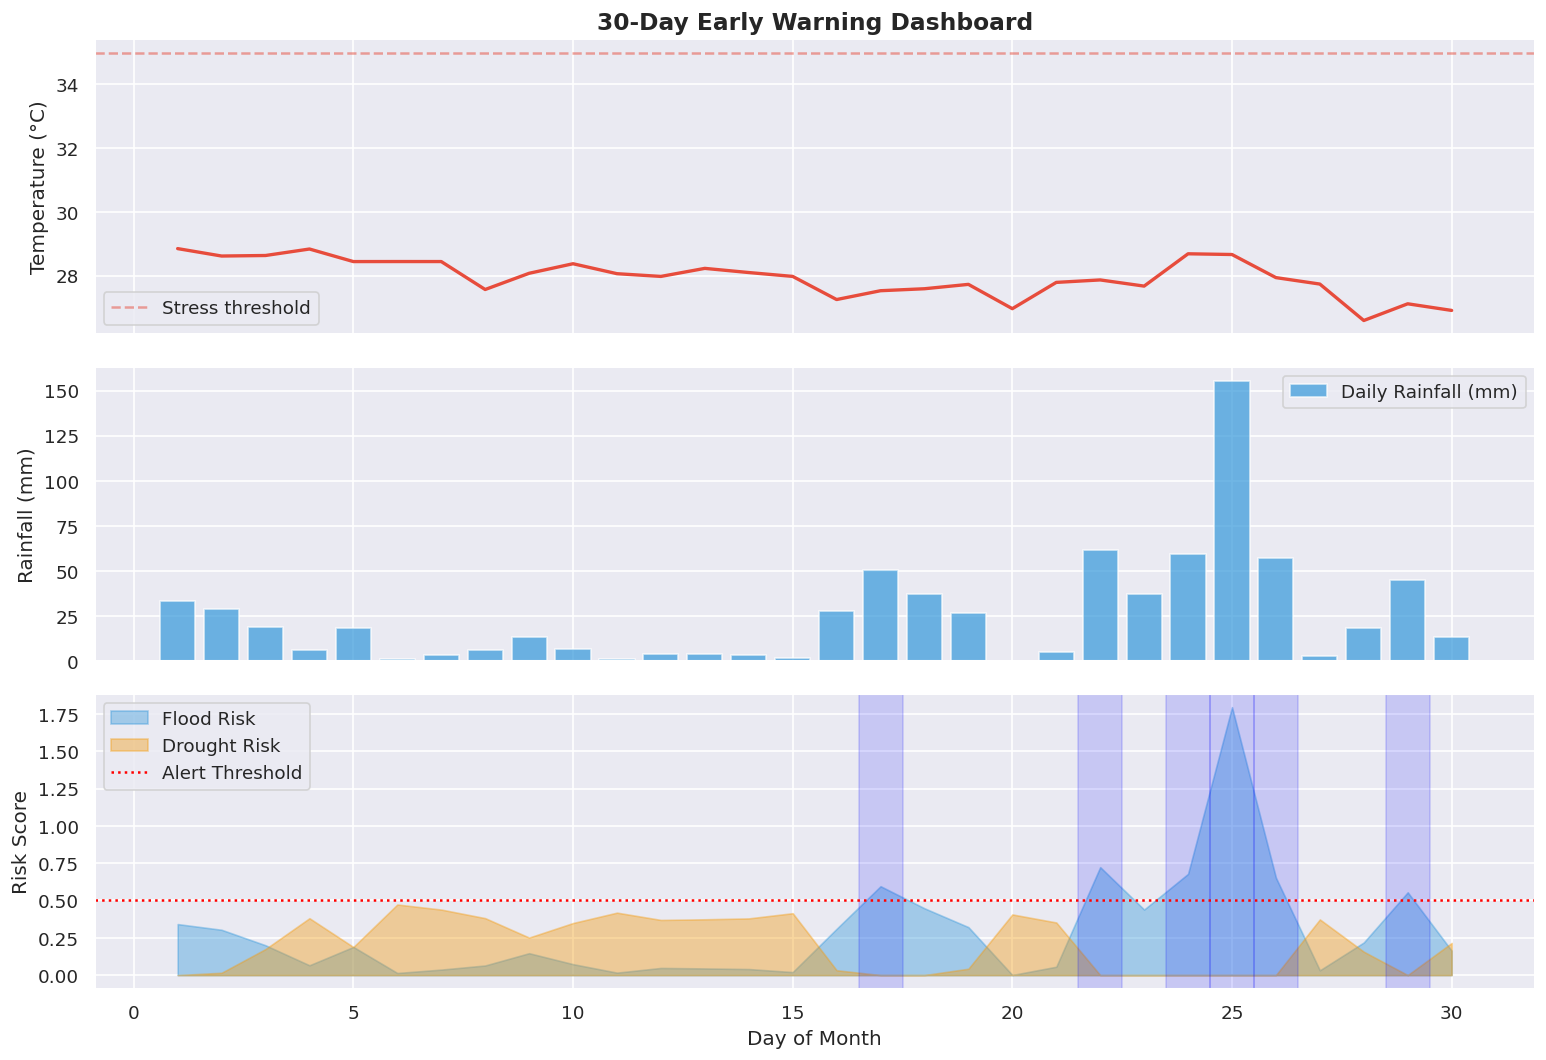

⚠️  High Flood Risk Days   : [np.int64(17), np.int64(22), np.int64(24), np.int64(25), np.int64(26), np.int64(29)]
⚠️  High Drought Risk Days : []


In [17]:
# Simulate 30-day risk trend for a single farm
np.random.seed(7)
days = np.arange(1, 31)

# Simulated environmental readings over 30 days
temp_trend = 28 + np.cumsum(np.random.randn(30) * 0.5)
rain_trend = np.where(days > 15, np.random.exponential(50, 30), np.random.exponential(10, 30))
moisture_trend = 50 + np.cumsum(np.random.randn(30) * 1.5)
moisture_trend = np.clip(moisture_trend, 10, 95)

# Compute flood and drought risk scores per day
flood_score   = (rain_trend * moisture_trend) / 5000
drought_score = np.clip((30 - rain_trend) / 30 * (1 - moisture_trend/100), 0, 1)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(days, temp_trend, color='#e74c3c', linewidth=2)
axes[0].axhline(35, color='#e74c3c', linestyle='--', alpha=0.5, label='Stress threshold')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('30-Day Early Warning Dashboard', fontsize=14, fontweight='bold')
axes[0].legend()

axes[1].bar(days, rain_trend, color='#3498db', alpha=0.7, label='Daily Rainfall (mm)')
axes[1].set_ylabel('Rainfall (mm)')
axes[1].legend()

axes[2].fill_between(days, flood_score, alpha=0.4, color='#3498db', label='Flood Risk')
axes[2].fill_between(days, drought_score, alpha=0.4, color='#f39c12', label='Drought Risk')
axes[2].axhline(0.5, color='red', linestyle=':', label='Alert Threshold')
axes[2].set_ylabel('Risk Score')
axes[2].set_xlabel('Day of Month')
axes[2].legend()

# Highlight high-risk days
high_flood   = days[flood_score > 0.5]
high_drought = days[drought_score > 0.5]
for d in high_flood:
    axes[2].axvspan(d-0.5, d+0.5, alpha=0.15, color='blue')
for d in high_drought:
    axes[2].axvspan(d-0.5, d+0.5, alpha=0.15, color='orange')

plt.tight_layout()
plt.show()

print(f'⚠️  High Flood Risk Days   : {list(high_flood)}')
print(f'⚠️  High Drought Risk Days : {list(high_drought)}')

---
## ✅ Summary

| Component | Details |
|---|---|
| **Dataset** | 3,000 samples, 14 raw + 5 engineered features |
| **Target Classes** | Normal, Disease, Drought, Flood |
| **Models** | Logistic Regression, Random Forest, XGBoost |
| **Explainability** | Feature Importance + SHAP |
| **Recommendation** | Rule-based action engine per risk class |
| **Monitoring** | 30-day early warning trend dashboard |

### 🚀 Possible Extensions
- Replace synthetic data with real data from [NASA POWER](https://power.larc.nasa.gov/) or [IMD Open API](https://mausam.imd.gov.in/)
- Add image-based disease detection using a CNN (ResNet/MobileNet) on plant photos
- Deploy as a Gradio / Streamlit web app
- Send SMS alerts to farmers via Twilio API when risk is HIGH/CRITICAL